In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from typing import Tuple

In [ ]:
def import_data() -> pd.DataFrame:
    """
    Import data from Housing_Price database into a pandas DataFrame.

    Returns:
        df (pd.DataFrame): The imported table from the database.
    """
    conn = psycopg2.connect(dsn = "host='host name' port='port' " \
    "dbname=Housing_Price " \
    "user=postgres " \
    "password='password'")

    df = pd.read_sql(sql = "SELECT * FROM clean_data_housing", con = conn)
    conn.close()

    return df

## analytic_linear_regression
Based on the formula we calculate the weights analytically for mean squared error.
$$
(X^{T} X)^{-1} X^{T} y = w
$$

In [115]:
def analytic_linear_regression(df: pd.DataFrame) -> np.ndarray:
    """
    Calculate the analytical solution for linear regression mean squared error.

    Args:
        df (pd.DataFrame): Data from the database.

    Returns:
        np.ndarray: Calculated based on the formula: (X^T * X)^{-1} * X^T * y
    """
    df = np.array(df).astype(float)
    X = df[:, :-1]
    y = df[:, -1]

    return np.linalg.inv(X.T @ X) @ X.T @ y, X, y

In [116]:
df = import_data()
weights, X, y = analytic_linear_regression(df)
print(weights)

/tmp/ipykernel_2116/2430265566.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql = "SELECT * FROM clean_data_housing", con = conn)


[ 5325.18017427 20431.32788945 11312.03893255  -158.99932137
  6584.34676846 16486.854077    2949.39205431]


Now we calculate Mean Squared Error, Room Mean Squared Error, Mean Absolute Error, $R^{2}$ Score.

#### MSE:
$$
\frac{1}{n}\Sigma(y - \hat y)^{2}
$$

#### RMSE:
$$
\sqrt{\frac{1}{n}\Sigma(y - \hat y)^{2}}
$$

#### MAE:
$$
\frac{1}{n}\Sigma|y - \hat y|
$$

#### $R^{2} Score:
$$
 1 - \frac{\sum_{i=1}^{n}(y_i - \hat y_i)^{2}}{\sum_{i=1}^{n}(y_i - \bar y_i)}
$$

In [117]:
def calculate_error(predictions: np.ndarray, y: np.ndarray) -> Tuple:
    """
    Calculate r2 score, Mean Squared Value, Root Mean Squared Value, Mean Absolute Value.

    Args:
        predictions (np.ndarray): Predictions of data.
        y (np.ndarray): True labels.

    Returns:
        (Tuple):
           - r2 (float): r2 score.
           - mse (float): Mean Squared Value.
           - rmse (float): Root Mean Squared Value.
           - mae (float): Mean Absolute Value.
    """
    r2 = r2_score(y_true = y, y_pred = predictions)
    mse = mean_squared_error(y_true = y, y_pred = predictions)
    rmse = root_mean_squared_error(y_true = y, y_pred = predictions)
    mae = mean_absolute_error(y_true = y, y_pred = predictions)

    return r2, mse, rmse, mae



In [118]:
predictions = X @ weights

r2, mse, rmse, mae = calculate_error(predictions, y)

print(f"R2 Score = {r2:.2f}\nMSE = {mse:.2f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}")

R2 Score = 0.88
MSE = 1129603648.74
RMSE = 33609.58
MAE = 26858.38


Just for observation print 15 random labels from the data and the predictions for them.

In [119]:
np.random.seed(10)
index = np.random.choice(a = len(y), size = 15, replace = False)
for y_true, predict in zip(y[index], predictions[index]):
    print(f"True Label = {y_true:.2f}        Prediction = {predict:.2f}")


True Label = 575630.00        Prediction = 549820.73
True Label = 272690.00        Prediction = 309553.09
True Label = 438317.00        Prediction = 490322.74
True Label = 562322.00        Prediction = 548643.03
True Label = 356293.00        Prediction = 309008.87
True Label = 458657.00        Prediction = 428865.84
True Label = 476292.00        Prediction = 472461.08
True Label = 550120.00        Prediction = 515296.10
True Label = 498553.00        Prediction = 453592.52
True Label = 329852.00        Prediction = 328645.39
True Label = 511957.00        Prediction = 560481.07
True Label = 500938.00        Prediction = 476717.24
True Label = 543711.00        Prediction = 487616.86
True Label = 542525.00        Prediction = 538694.96
True Label = 394097.00        Prediction = 357647.42


Text(0.5, 0.92, 'Housing price')

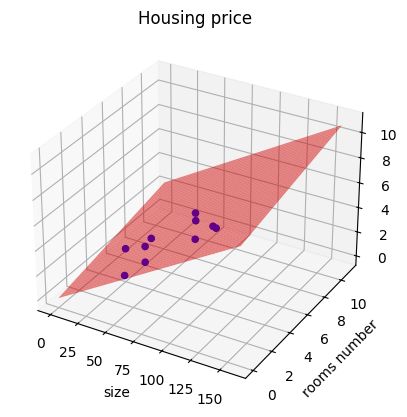

In [143]:
fig, ax = plt.subplots(subplot_kw = {'projection': '3d'})

size = X[:, 0]
rooms_num = X[:, 1]

size_range = np.linspace(0, 160, 200)
rooms_num_range = np.linspace(0, 11, 200)

grid = np.stack(np.meshgrid(size_range, rooms_num_range), axis = -1)

prediction_plane = grid @ weights[0:2]

ax.plot_surface(grid[:, :, 0], grid[:, :, 1], prediction_plane / 100000, color = "red", alpha = 0.5)

# Choose 10 data points randomly
random_points = np.random.choice(len(size), size = 10, replace = False)
# Plot these points
ax.scatter3D(size[random_points], rooms_num[random_points], y[random_points] / 100000, color = "blue", alpha = 1)

ax.set_xlabel("size")
ax.set_ylabel("rooms number")
ax.set_zlabel("price")
ax.set_title("Housing price")
